#  Breast Cancer Detection using Deep Learning
A deep learning model to classify breast ultrasound images into benign, malignant, and normal categories.

##  Import Required Libraries
Loading all the necessary Python libraries for image processing, deep learning, and visualization.

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

✅ Dataset Loaded: (1578, 224, 224, 3), Labels: (1578,)


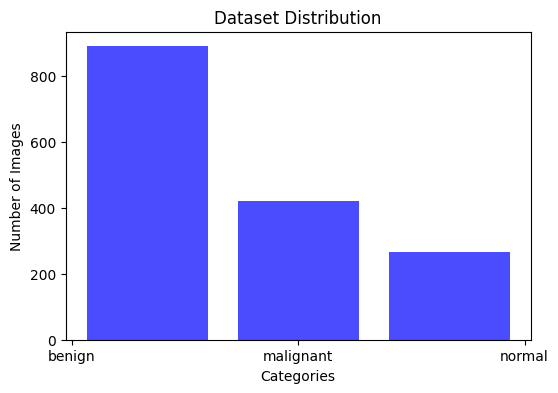

In [14]:
dataset_path = "Dataset_BUSI_with_GT"
categories = ["benign", "malignant", "normal"]

data = []
labels = []

# Load Images
for category in categories:
    category_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)  # Read in color
        img = cv2.resize(img, (224, 224))  # Resize to 224x224 (standard for CNNs)
        data.append(img)
        labels.append(categories.index(category))  # Assign numeric labels

# Convert lists to numpy arrays
data = np.array(data) / 255.0  # Normalize pixel values
labels = np.array(labels)

print(f"✅ Dataset Loaded: {data.shape}, Labels: {labels.shape}")

# Check dataset distribution
plt.figure(figsize=(6,4))
plt.hist(labels, bins=3, rwidth=0.8, color='blue', alpha=0.7)
plt.xticks([0, 1, 2], categories)
plt.xlabel("Categories")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.show()


In [15]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Convert labels to one-hot encoding (since we have 3 categories)
labels = to_categorical(labels, num_classes=3)

# Split into train & test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42, stratify=labels)

# Image Augmentation to generate more diverse images
datagen = ImageDataGenerator(
    rotation_range=20,  
    width_shift_range=0.1,  
    height_shift_range=0.1,  
    shear_range=0.1,  
    zoom_range=0.1,  
    horizontal_flip=True,  
    fill_mode="nearest"
)

# Display data shapes
print(f"✅ Training Data Shape: {X_train.shape}, Labels: {y_train.shape}")
print(f"✅ Testing Data Shape: {X_test.shape}, Labels: {y_test.shape}")

✅ Training Data Shape: (1262, 224, 224, 3), Labels: (1262, 3)
✅ Testing Data Shape: (316, 224, 224, 3), Labels: (316, 3)


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Define CNN model
model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    # Second Convolutional Block
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    # Third Convolutional Block
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    # Flattening & Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # 3 classes: Normal, Benign, Malignant
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model Summary
model.summary()


C:\Users\gargm_h0ogsub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,243 (42.61 MB)

 Trainable params: 11,169,795 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
'''# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,  # You can increase this for better performance
    batch_size=32
)
'''

from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reduce learning rate if validation loss doesn't improve for 3 epochs
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6)

# Train the model for more epochs
history = model.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    epochs=30, batch_size=32, 
    callbacks=[lr_scheduler]
)


Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 151s 4s/step - accuracy: 0.5075 - loss: 15.5924 - val_accuracy: 0.1930 - val_loss: 21.8385 - learning_rate: 0.0010
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.6768 - loss: 2.8778 - val_accuracy: 0.1677 - val_loss: 56.3251 - learning_rate: 0.0010
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.6924 - loss: 2.4741 - val_accuracy: 0.1677 - val_loss: 92.2169 - learning_rate: 0.0010
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.7120 - loss: 1.3182 - val_accuracy: 0.1677 - val_loss: 44.2406 - learning_rate: 0.0010
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.7405 - loss: 1.1192 - val_accuracy: 0.1677 - val_loss: 46.7681 - learning_rate: 5.0000e-04
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.7715 - loss: 0.7214 - val_accuracy: 0.1741 - val_loss: 34.3658 - learning_rate: 5.0000e-04
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.7631 - loss: 0

In [18]:
# Save the model
model.save("breast_cancer_model.h5")

# Save the training history
import json
with open('training_history.json', 'w') as f:
    json.dump(history.history, f)

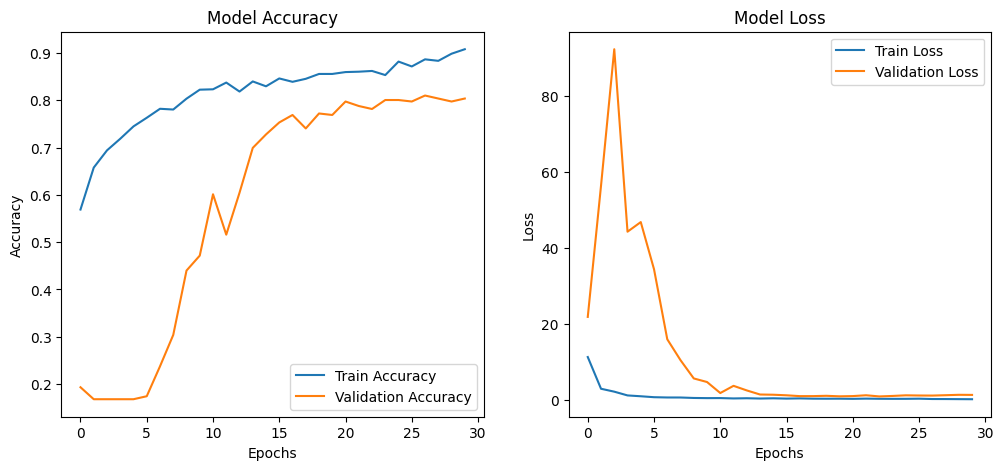

"\nimport matplotlib.pyplot as plt\n\n# Plot accuracy\nplt.figure(figsize=(12, 5))\nplt.subplot(1, 2, 1)\nplt.plot(history.history['accuracy'], label='Train Accuracy')\nplt.plot(history.history['val_accuracy'], label='Validation Accuracy')\nplt.xlabel('Epochs')\nplt.ylabel('Accuracy')\nplt.legend()\nplt.title('Model Accuracy')\n\n# Plot loss\nplt.subplot(1, 2, 2)\nplt.plot(history.history['loss'], label='Train Loss')\nplt.plot(history.history['val_loss'], label='Validation Loss')\nplt.xlabel('Epochs')\nplt.ylabel('Loss')\nplt.legend()\nplt.title('Model Loss')\n\nplt.show()\n"

In [19]:
# Load the saved history
import json
with open('training_history.json', 'r') as f:
    history_dict = json.load(f)

# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Train Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()



'''
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()
'''


In [20]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import os

# Load the trained model
model_path = "breast_cancer_model.h5"  # Ensure this file exists
model = tf.keras.models.load_model(model_path)

# Define image preprocessing function
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))  # Adjust based on training size
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize (if required)
    return img_array

# Path to your dataset folders
dataset_folder = "Dataset_BUSI_with_GT"

# Loop through each category folder
categories = ["benign", "malignant", "normal"]
for category in categories:
    category_path = os.path.join(dataset_folder, category)
    if not os.path.exists(category_path):
        print(f"Folder not found: {category_path}")
        continue  # Skip if folder is missing
    
    print(f"\n🔍 Processing images from category: {category}")

    # Get all image files
    # image_files = [os.path.join(category_path, f) for f in os.listdir(category_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    image_files = [os.path.join(category_path, f) for f in os.listdir(category_path) 
               if f.endswith(('.png', '.jpg', '.jpeg')) and '_mask' not in f]

    for img_path in image_files:
        # Load and preprocess the image
        img_array = preprocess_image(img_path)

        # Make prediction
        predictions = model.predict(img_array)
        predicted_class = np.argmax(predictions, axis=1)[0]

        # Map prediction to label
        labels = ["benign", "malignant", "normal"]  # Ensure your model follows this order
        predicted_label = labels[predicted_class]

        # Display results
        print(f"📌 Image: {os.path.basename(img_path)}  --> Predicted: {predicted_label}")



🔍 Processing images from category: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
📌 Image: benign (1).png  --> Predicted: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
📌 Image: benign (10).png  --> Predicted: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
📌 Image: benign (100).png  --> Predicted: malignant
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
📌 Image: benign (101).png  --> Predicted: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
📌 Image: benign (102).png  --> Predicted: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
📌 Image: benign (103).png  --> Predicted: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
📌 Image: benign (104).png  --> Predicted: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
📌 Image: benign (105).png  --> Predicted: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
📌 Image: benign (106).png  --> Predicted: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
📌 Image: benign (107).png  --> Predicted: benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
📌 Image: benign (108).png  --> Predicted: benig

In [21]:
from collections import Counter

# Store actual vs predicted labels
actual_labels = []
predicted_labels = []

# Modify loop to store predictions
for category in categories:
    category_path = os.path.join(dataset_folder, category)
    if not os.path.exists(category_path):
        continue  # Skip if folder is missing

    image_files = [os.path.join(category_path, f) for f in os.listdir(category_path) 
                   if f.endswith(('.png', '.jpg', '.jpeg')) and '_mask' not in f]

    for img_path in image_files:
        img_array = preprocess_image(img_path)
        predictions = model.predict(img_array)
        predicted_class = np.argmax(predictions, axis=1)[0]
        
        labels = ["benign", "malignant", "normal"]  # Ensure this order matches training labels
        predicted_label = labels[predicted_class]

        actual_labels.append(category)  # True category
        predicted_labels.append(predicted_label)  # Model's prediction

# Count misclassifications
misclassified = [(true, pred) for true, pred in zip(actual_labels, predicted_labels) if true != pred]

# Print misclassification summary
print("\n📊 Misclassified Images:")
for true, pred in misclassified:
    print(f"❌ Actual: {true} → Predicted: {pred}")

# Print class-wise count
print("\n📈 Prediction Distribution:")
print(Counter(predicted_labels))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━


📊 Classification Report:
              precision    recall  f1-score   support

      benign       0.90      0.98      0.94       437
   malignant       0.95      0.90      0.92       210
      normal       0.96      0.79      0.87       133

    accuracy                           0.92       780
   macro avg       0.94      0.89      0.91       780
weighted avg       0.93      0.92      0.92       780



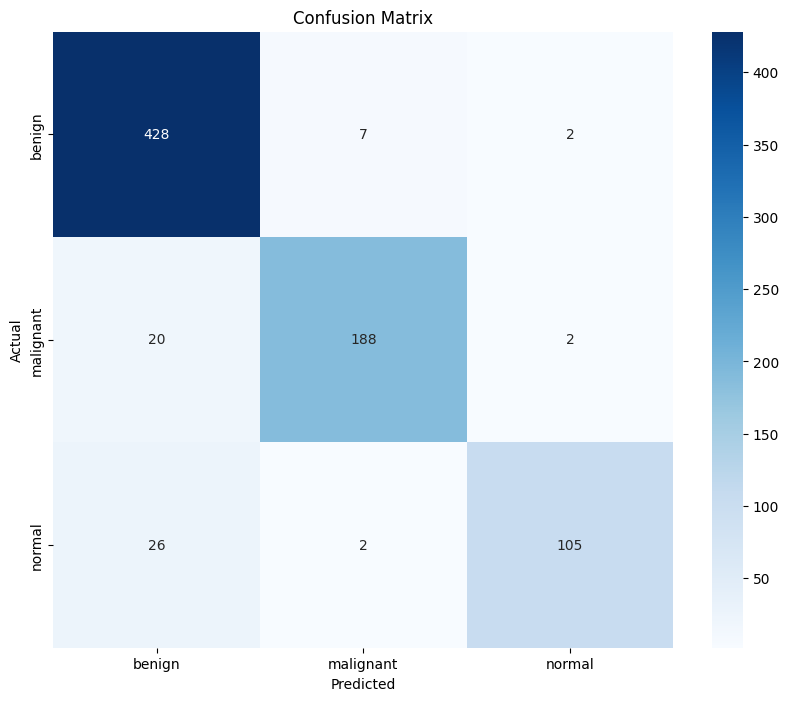


📈 Class-wise Accuracy:
benign: 97.94%
malignant: 89.52%
normal: 78.95%


In [22]:
# Required imports
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Define paths and categories
dataset_folder = "Dataset_BUSI_with_GT"
categories = ["benign", "malignant", "normal"]

# Store actual vs predicted labels
actual_labels = []
predicted_labels = []

# Collect predictions
for category in categories:
    category_path = os.path.join(dataset_folder, category)
    if not os.path.exists(category_path):
        continue

    image_files = [os.path.join(category_path, f) for f in os.listdir(category_path) 
                   if f.endswith(('.png', '.jpg', '.jpeg')) and '_mask' not in f]

    for img_path in image_files:
        img_array = preprocess_image(img_path)
        predictions = model.predict(img_array, verbose=0)
        predicted_class = np.argmax(predictions, axis=1)[0]
        
        labels = ["benign", "malignant", "normal"]
        predicted_label = labels[predicted_class]

        actual_labels.append(category)
        predicted_labels.append(predicted_label)

# Rest of the evaluation code remains the same
print("\n📊 Classification Report:")
report = classification_report(actual_labels, predicted_labels, target_names=categories)
print(report)

# Create and plot confusion matrix
cm = confusion_matrix(actual_labels, predicted_labels, labels=categories)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=categories, 
            yticklabels=categories)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate and display class-wise accuracy
print("\n📈 Class-wise Accuracy:")
for i, category in enumerate(categories):
    class_correct = cm[i][i]
    class_total = sum(cm[i])
    accuracy = class_correct / class_total * 100
    print(f"{category}: {accuracy:.2f}%")

# Save the evaluation results
with open('evaluation_results.txt', 'w') as f:
    f.write("Breast Cancer Detection Model Evaluation\n")
    f.write("=====================================\n\n")
    f.write("Classification Report:\n")
    f.write(report)
    f.write("\n\nClass-wise Accuracy:\n")
    for i, category in enumerate(categories):
        class_correct = cm[i][i]
        class_total = sum(cm[i])
        accuracy = class_correct / class_total * 100
        f.write(f"{category}: {accuracy:.2f}%\n")

Done till here 

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 521ms/step


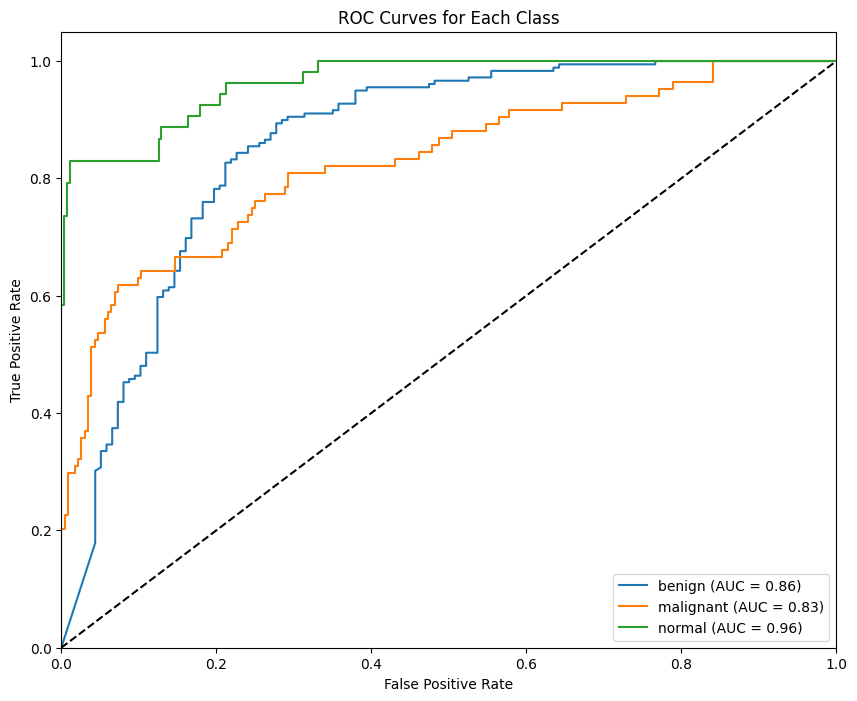

In [37]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predictions for all test images
y_pred_proba = model.predict(X_test)

# Calculate ROC curve and AUC for each class
plt.figure(figsize=(10, 8))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{categories[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Each Class')
plt.legend(loc="lower right")
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 476ms/step


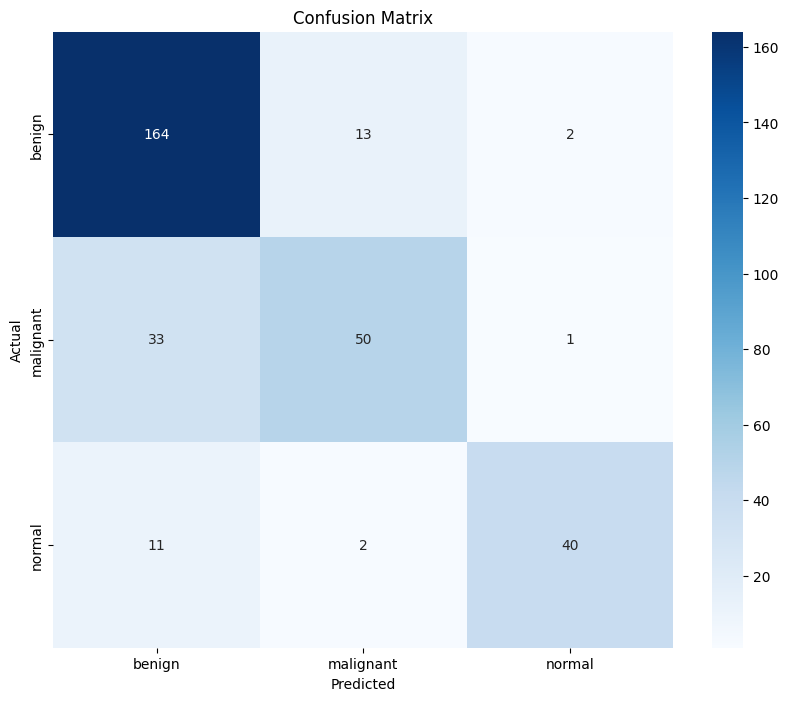

In [38]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories,
            yticklabels=categories)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

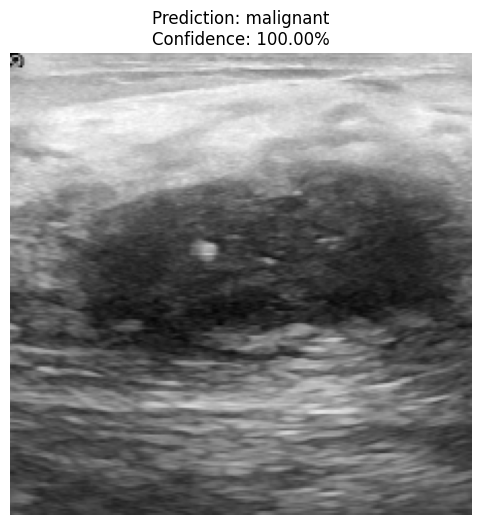


Predicted class: malignant
Confidence: 100.00%


In [41]:
# Function to predict single image
def predict_single_image(image_path):
    # Load and preprocess image
    img_array = preprocess_image(image_path)
    
    # Get prediction
    predictions = model.predict(img_array, verbose=0)
    pred_class = np.argmax(predictions[0])
    confidence = predictions[0][pred_class] * 100
    
    # Display results
    plt.figure(figsize=(6, 6))
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Prediction: {categories[pred_class]}\nConfidence: {confidence:.2f}%')
    plt.axis('off')
    plt.show()
    
    return categories[pred_class], confidence

# Test the single image prediction
test_image_path = os.path.join(dataset_folder, "malignant", "malignant (1).png")
prediction, conf = predict_single_image(test_image_path)
print(f"\nPredicted class: {prediction}")
print(f"Confidence: {conf:.2f}%")

In [42]:
# Get predictions for test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Generate and save project summary
from sklearn.metrics import classification_report

summary_report = classification_report(y_test_classes, y_pred_classes, target_names=categories)
print("\nClassification Report:")
print(summary_report)

with open('project_summary.txt', 'w') as f:
    f.write("Breast Cancer Detection Model Summary\n")
    f.write("===================================\n\n")
    
    # Model Performance
    f.write("Model Performance Metrics:\n")
    f.write(summary_report)
    
    # Dataset Information
    f.write("\nDataset Distribution:\n")
    for i, category in enumerate(categories):
        count = np.sum(y_test_classes == i)
        f.write(f"{category}: {count} images\n")
    
    # Training Parameters
    f.write("\nTraining Parameters:\n")
    f.write(f"Input Image Size: 224x224x3\n")
    f.write(f"Number of Classes: 3\n")
    f.write(f"Training-Test Split: 80-20\n")

print("\nProject summary has been saved to 'project_summary.txt'")

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 505ms/step

Classification Report:
              precision    recall  f1-score   support

      benign       0.79      0.92      0.85       179
   malignant       0.77      0.60      0.67        84
      normal       0.93      0.75      0.83        53

    accuracy                           0.80       316
   macro avg       0.83      0.76      0.78       316
weighted avg       0.81      0.80      0.80       316


Project summary has been saved to 'project_summary.txt'


In [44]:
# Create directory for report figures
report_dir = "report_figures"
if not os.path.exists(report_dir):
    os.makedirs(report_dir)

# Save confusion matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories,
            yticklabels=categories)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig(os.path.join(report_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.close()

# Save ROC curves
plt.figure(figsize=(10, 8))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{categories[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.savefig(os.path.join(report_dir, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.close()

print(f"Files saved in: {os.path.abspath(report_dir)}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 468ms/step
Files saved in: d:\Sem - 4\Machine Learning\MammoDetect\report_figures


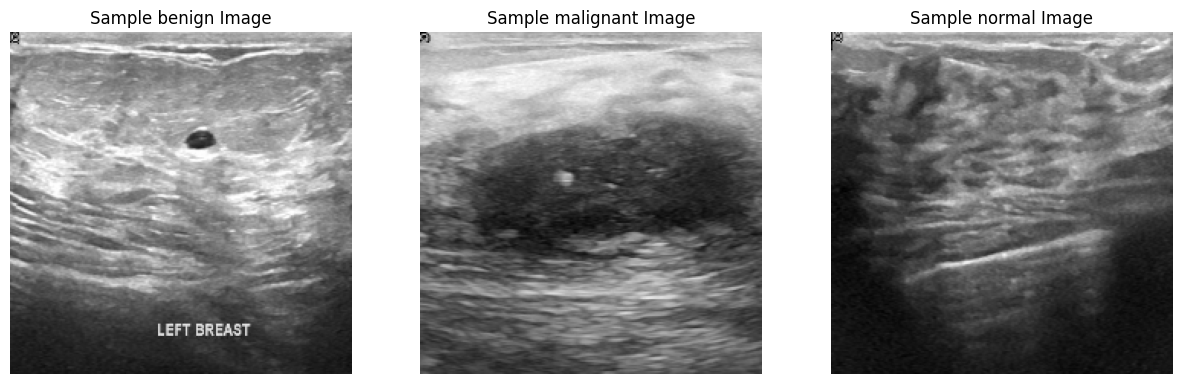

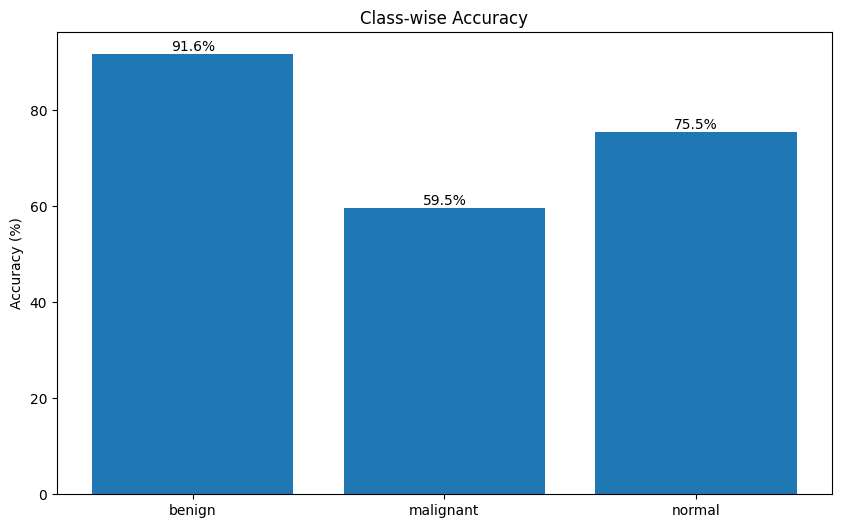

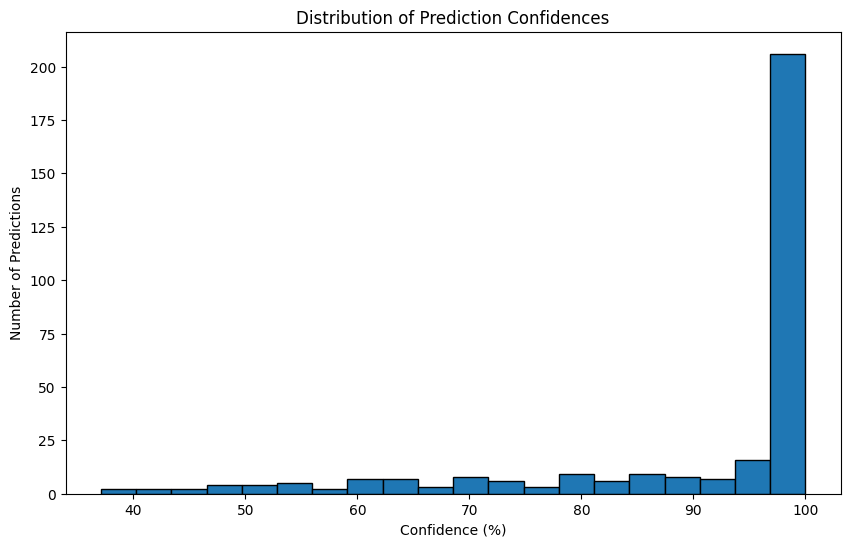


All figures have been saved and displayed


In [47]:
# 1. Sample Images from Each Category
plt.figure(figsize=(15, 5))
for idx, category in enumerate(categories):
    plt.subplot(1, 3, idx+1)
    img_path = os.path.join(dataset_folder, category, os.listdir(os.path.join(dataset_folder, category))[0])
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Sample {category} Image')
    plt.axis('off')
plt.savefig(os.path.join(report_dir, 'sample_images.png'), dpi=300, bbox_inches='tight')
plt.show()  # Display in notebook

# 2. Class-wise Accuracy Bar Plot
class_accuracies = []
for i in range(len(categories)):
    mask = y_test_classes == i
    class_acc = accuracy_score(y_test_classes[mask], y_pred_classes[mask])
    class_accuracies.append(class_acc * 100)

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, class_accuracies)
plt.title('Class-wise Accuracy')
plt.ylabel('Accuracy (%)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom')
plt.savefig(os.path.join(report_dir, 'class_accuracies.png'), dpi=300, bbox_inches='tight')
plt.show()  # Display in notebook

# 3. Prediction Confidence Distribution
plt.figure(figsize=(10, 6))
confidences = np.max(y_pred, axis=1) * 100
plt.hist(confidences, bins=20, edgecolor='black')
plt.title('Distribution of Prediction Confidences')
plt.xlabel('Confidence (%)')
plt.ylabel('Number of Predictions')
plt.savefig(os.path.join(report_dir, 'confidence_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()  # Display in notebook

print("\nAll figures have been saved and displayed")